# 02 - Multiple Linear Regression End-to-End

This saved notebook includes visible embedded visual outputs plus runnable code for multiple regression.

## Problem
Predict `sales_k_units` from marketing spend, price, competitor spend, and season. Coefficients are interpreted **holding other variables constant**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.formula.api as smf
DATA_DIR = Path.cwd().parent / 'data' if (Path.cwd().parent / 'data').exists() else Path.cwd() / 'data'
print('Libraries imported.')
print('Dataset path resolved.')

Libraries imported.
Dataset path resolved.


In [2]:
df = pd.read_csv(DATA_DIR / 'multiple_regression_marketing_sales.csv')
df.head(3)

  campaign_id  tv_spend_k  radio_spend_k  social_spend_k  price_index  competitor_spend_k season  sales_k_units
0        C001      146.00          64.71           18.72       116.35              164.96     Q2          67.05
1        C002       22.08          73.15           36.77       118.69               71.61     Q3          23.68
2        C003      142.26          65.27           28.03        93.91              138.89     Q1          85.06

## Average sales by season
The bar chart below is embedded in the saved notebook.

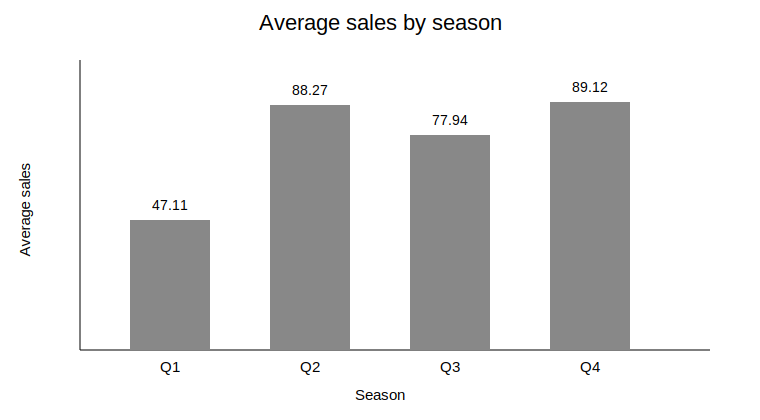

season
Q1    47.11
Q2    88.27
Q3    77.94
Q4    89.12
Name: sales_k_units, dtype: float64

In [3]:
season_sales = df.groupby('season')['sales_k_units'].mean().sort_index().round(2)
plt.figure(figsize=(7,4))
plt.bar(season_sales.index, season_sales.values)
plt.title('Average sales by season')
plt.show()
season_sales

In [4]:
numeric_features = ['tv_spend_k','radio_spend_k','social_spend_k','price_index','competitor_spend_k']
categorical_features = ['season']
target = 'sales_k_units'
X = df[numeric_features + categorical_features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=43)
preprocess = ColumnTransformer([('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features), ('numeric', 'passthrough', numeric_features)])
pipeline = Pipeline([('preprocess', preprocess), ('model', LinearRegression())])
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
pd.DataFrame({'metric':['MAE','RMSE','R2'], 'value':[mean_absolute_error(y_test,pred), np.sqrt(mean_squared_error(y_test,pred)), r2_score(y_test,pred)]})

  metric     value
0    MAE  6.803410
1   RMSE  9.007675
2     R2  0.959718

## Coefficient interpretation
Positive coefficients increase predicted sales; negative coefficients decrease predicted sales, holding other variables constant.

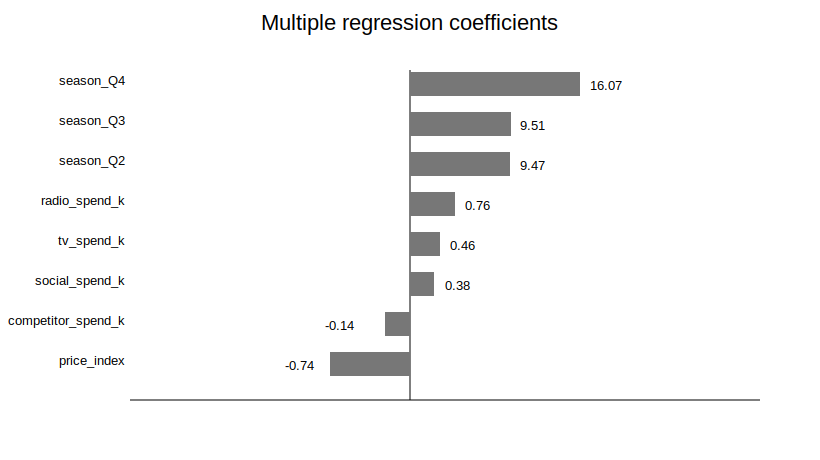

                       feature  coefficient
2       categorical__season_Q4    16.074842
1       categorical__season_Q3     9.514449
0       categorical__season_Q2     9.473192
4       numeric__radio_spend_k     0.761870
3          numeric__tv_spend_k     0.456565
5      numeric__social_spend_k     0.376357
7 numeric__competitor_spend_k    -0.141192
6        numeric__price_index    -0.744473

In [5]:
feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': pipeline.named_steps['model'].coef_}).sort_values('coefficient', ascending=False)
coef_table.plot(kind='barh', x='feature', y='coefficient', figsize=(9,5))
plt.title('Multiple regression coefficients')
plt.show()
coef_table

In [6]:
ols = smf.ols('sales_k_units ~ tv_spend_k + radio_spend_k + social_spend_k + price_index + competitor_spend_k + C(season)', data=df).fit()
pd.DataFrame({'coefficient': ols.params, 'p_value': ols.pvalues, 'lower_95': ols.conf_int()[0], 'upper_95': ols.conf_int()[1]}).sort_values('p_value').head()

                       coefficient       p_value   lower_95   upper_95
tv_spend_k                0.450606  1.983393e-73   0.435466   0.465746
radio_spend_k             0.803542  7.038510e-41   0.728193   0.878891
price_index              -0.749053  2.496985e-16  -0.900427  -0.597678
competitor_spend_k       -0.152480  6.154205e-14  -0.192229  -0.112731
social_spend_k            0.402834  4.656125e-12   0.297521   0.508147

## Final interpretation
The model has strong predictive performance on the synthetic dataset. TV, radio, and social spend are positively associated with sales; price index and competitor spend are negatively associated with sales.